In [ ]:
# Steps:
# Preprocess +EDA +Feature Selection
# Extract input and output columns
# Scale the values
# Train tst Split
# Train the Model
# Evalute the model/model selection
# Deploy the model

In [ ]:
# PREPROCESSING

In [2]:
import  pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/content/placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()#koi bi value null nahi h ab yaha pur

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
#ab ye colum (Unnamed: 0) kam ka nahi h is liye hum isko hata denghe
df=df.iloc[:,1:]#is ka matlb ke mujhe dataset ke sare columns chaheye lekin onward 1 colm ke or expact colum 1

In [9]:
df.head() #ab data meinse wo col easily remove hogia h

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
#EDA


In [11]:
import matplotlib.pyplot as plt

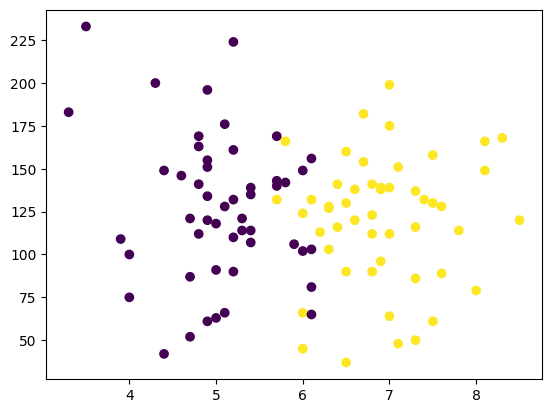

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])#eda kurne se hamein thora idea agia ke yaha pur konsa model hum use kursakte h
#ab hum yaha pur logistic regresion model use kre ghe

In [14]:
#FEATURE SELECTION
#ab hum seect kre ghe ke konse features hamein rakhne h apne dtaset mein or konse
# nikalne h to yaha pur sare hi important h features to is liye is step ko ignore mare ghe


In [15]:
# Extract input and output columns

Hamre data set mein 2 qisum ke features ki catogiry hote h

1) Dependent features jo ke yaha pur placement h or use hu output ni kehte h

2) Independent variables jo ke yaha pur h cgpa and iq or is ko hum input bi keh sakte  

In [16]:
#ab hum independent and dependent variales ko alug alug kisi variable
# mein rakhe ghe

In [17]:
X=df.iloc[:,0:2]#is ka matl h ke mujhe sare colum chaheye o se lekur 2 tuk iska matlb 0 and 1 siruf 2 hi

In [18]:
Y=df.iloc[:,-1]

In [23]:
X,X.shape

(    cgpa     iq
 0    6.8  123.0
 1    5.9  106.0
 2    5.3  121.0
 3    7.4  132.0
 4    5.8  142.0
 ..   ...    ...
 95   4.3  200.0
 96   4.4   42.0
 97   6.7  182.0
 98   6.3  103.0
 99   6.2  113.0
 
 [100 rows x 2 columns],
 (100, 2))

In [21]:
Y,Y.shape

(0     1
 1     0
 2     0
 3     1
 4     0
      ..
 95    0
 96    0
 97    1
 98    1
 99    1
 Name: placement, Length: 100, dtype: int64,
 (100,))

In [24]:
# Train tst Split

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [30]:
X_test

,cgpa,iq
67,5.0,118.0
69,8.5,120.0
78,6.1,81.0
73,4.9,61.0
84,5.7,169.0
4,5.8,142.0
89,4.9,151.0
36,5.7,140.0
44,7.5,61.0
10,6.0,45.0


In [31]:
X_test

,cgpa,iq
67,5.0,118.0
69,8.5,120.0
78,6.1,81.0
73,4.9,61.0
84,5.7,169.0
4,5.8,142.0
89,4.9,151.0
36,5.7,140.0
44,7.5,61.0
10,6.0,45.0


In [32]:
Y_train

,placement
45,1
19,0
28,0
22,0
58,1
...,...
6,0
13,1
70,1
11,1


In [33]:
Y_test

,placement
67,0
69,1
78,0
73,0
84,0
4,0
89,0
36,0
44,1
10,1


In [34]:
# Scale the values

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler=StandardScaler()

In [38]:
X_train=scaler.fit_transform(X_train)

In [39]:
X_train

array([[ 0.00973142, -1.51006165],
       [-0.6909309 ,  0.17282131],
       [-0.6909309 , -0.89810421],
       [-0.95367927, -0.13315741],
       [ 1.76138722, -1.17858471],
       [-0.95367927,  0.75928053],
       [-1.21642764,  0.52979649],
       [-2.35500391,  1.47323088],
       [-0.51576532,  0.3513089 ],
       [-1.74192438, -0.64312194],
       [ 0.71039374, -0.33714322],
       [ 1.23589048,  0.17282131],
       [-1.04126206,  0.40230536],
       [-0.6909309 ,  0.91226989],
       [-0.07785137, -0.49013258],
       [ 2.02413559,  1.09075748],
       [ 0.09731421,  0.78477876],
       [-0.77851369,  1.29474329],
       [ 0.71039374,  0.40230536],
       [ 0.00973142, -0.59212549],
       [ 1.84897001,  1.03976103],
       [-1.12884485, -1.86703683],
       [ 0.44764537, -0.89810421],
       [ 0.09731421,  0.17282131],
       [ 0.88555932,  1.26924507],
       [ 0.97314211,  0.65728762],
       [ 0.62281095,  1.44773266],
       [-0.86609648, -1.58655633],
       [ 0.09731421,

In [40]:
X_test=scaler.fit_transform(X_test)

In [41]:
X_test

array([[-0.91632832,  0.22245597],
       [ 2.25906684,  0.27081596],
       [ 0.08165302, -0.6722039 ],
       [-1.00705389, -1.15580383],
       [-0.28124929,  1.45563579],
       [-0.19052371,  0.80277589],
       [-1.00705389,  1.02039585],
       [-0.28124929,  0.75441589],
       [ 1.35181108, -1.15580383],
       [-0.00907256, -1.54268378]])

In [42]:
# Train the Model

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
clf=LogisticRegression()

In [46]:
clf.fit(X_train,Y_train)

LogisticRegression()

In [47]:
# Evalute the model

In [48]:
#is mein hum model ki accuracy nikalte h

In [53]:
Y_predict=clf.predict(X_test) #ye h mere model ka prediction

In [51]:
Y_test #ye h achual mere model ke liye jo mene test kurne ke liye data alug kia tha


,placement
67,0
69,1
78,0
73,0
84,0
4,0
89,0
36,0
44,1
10,1


In [52]:
#ab hum dekhe ghe ke kitna is ne acurate dia h prediction or ye hum khud se bi kurdkte h
#wurna scikit lurn ka bi use kurskte h

In [55]:
from sklearn.metrics import accuracy_score

In [56]:
accuracy_score(Y_test,Y_predict)

0.9

In [58]:
accuracy_score(Y_test,Y_predict)*100  # ab is ne hame bataya h ke model ne 90 percent sahi predict kia h

90.0

How to plot the Decision Boundry **bold text**

Decision Boundry hum kehte h kemechine learnin model ne kia pattern notice kiahamare data mein us ko visualize kurna

In [60]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

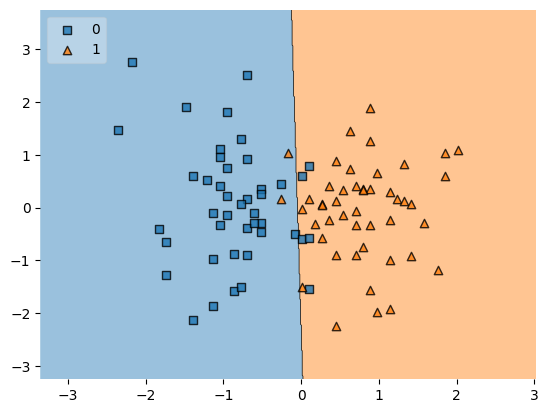

In [63]:
#ploting decision Region
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2) # Y_train.values hum ne is liye kia h ke us ko numpy array chaheye

In [64]:
# hamein is se pata chala ke hamare algorthim ne kis traha data ko dekha or kis trah ka patern banaya

In [ ]:
# ab bus yehi last step h model training ya selection ka agur sahi nahi deraha to hum koi or mode select kre ghe wurna model traing bus yahi tuk thi

In [65]:
# python mein aik libraray h
import pickle
# ye library kia kurte h ye kisi bi object ko file mein convert kurdeta h
# or phir hum us file ko utha kur hum kisi bi or enviroment mein use kurskte h


In [66]:
pickle.dump(clf,open('model.pkl','wb')) # clf ko hum ne export kurna h
# open('model.pkl','wb' ye code file banane ke liye use hota h
# model.pkl file ka name and wb ka matlb write binary mode

In [67]:
#  model.pkl ab ye agia hogha hamae same directory mein yehi hamara mechine learning model h

In [ ]:
# ab hum is model ko utha kur kisi bi website mein jake integrete kursakte h